In [1]:
import pandas as pd
from geopy.geocoders import Nominatim

# Загрузка данных

In [2]:
# %%capture
# !wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [3]:
ford_price_data = pd.read_excel('Data/data_ford_price.xlsx')

Найдём конкретный адрес нулевого объекта, используя широту и долготу. Для этого нам понадобится библиотека geopy.

# Обработка географических данных

In [4]:
# Создаём объект Nominatim и инициализируем API Nominatim с помощью параметра my_email@myserver.com.
geolocator = Nominatim(user_agent="my_email@myserver.com")

Объединим широту и долготу для поиска адреса нулевого объекта:

In [5]:
Latitude = str(ford_price_data['lat'][0])
Longitude =  str(ford_price_data['long'][0])
location = geolocator.reverse(Latitude+","+Longitude)
print(location)

Fort Henry Drive, Kingsport, Sullivan County, East Tennessee, Tennessee, 37663, United States


Теперь получим информацию из данного списка и преобразуем её в словарь с помощью функции raw():

In [6]:
address = location.raw['address']
address

{'road': 'Fort Henry Drive',
 'city': 'Kingsport',
 'county': 'Sullivan County',
 'region': 'East Tennessee',
 'state': 'Tennessee',
 'ISO3166-2-lvl4': 'US-TN',
 'postcode': '37663',
 'country': 'United States',
 'country_code': 'us'}

# Отрисовка карты

С помощью библиотек geopandas и shapely можно визуализировать географические данные. Это значит, что мы можем увидеть расположение наших объектов (автомобилей) на карте мира.

In [7]:
#!pip install geopandas
#!pip install shapely
#!pip install geodatasets

In [8]:
import geopandas as gpd
from geodatasets import get_path
from shapely.geometry import Point
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt

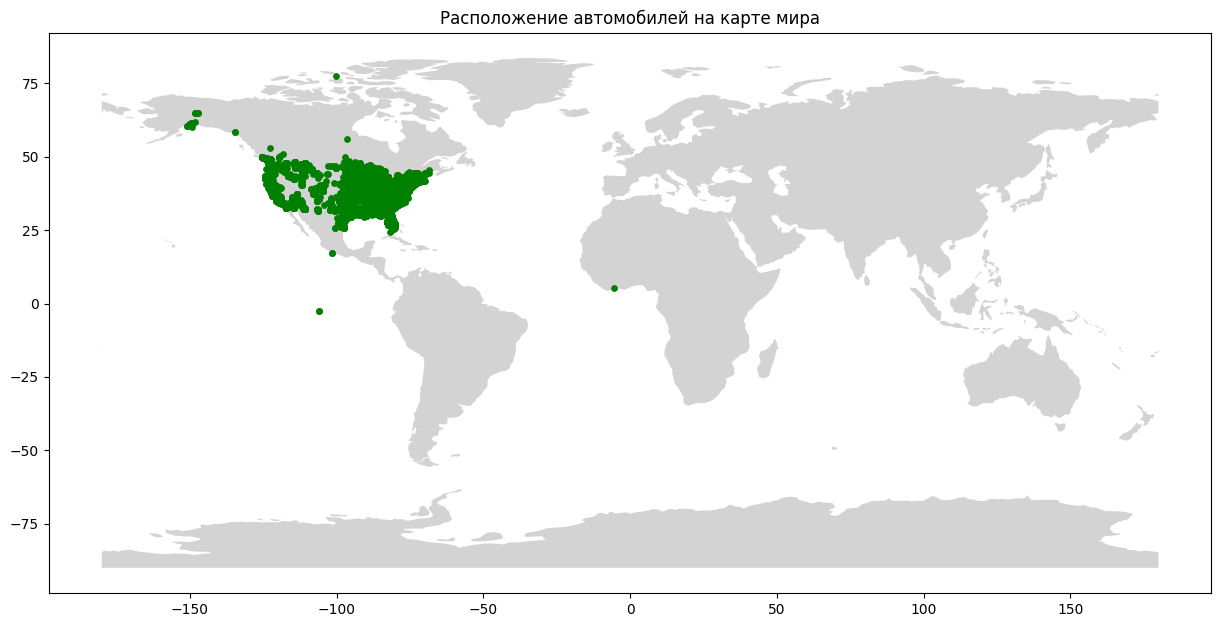

In [9]:
# Создаём геометрию
geometry = [Point(xy) for xy in zip(ford_price_data['long'], ford_price_data['lat'])]
gdf = GeoDataFrame(ford_price_data, geometry=geometry)

# Загружаем карту мира
world = gpd.read_file(get_path("naturalearth.land"))

# Отрисовка
fig, ax = plt.subplots(figsize=(15, 15))
world.plot(ax=ax, color='lightgray')
gdf.plot(ax=ax, marker='o', color='green', markersize=15)

plt.title('Расположение автомобилей на карте мира')
plt.show()

In [10]:
import plotly.express as px
 
fig = px.scatter_geo(ford_price_data, lat='lat', lon='long', hover_name="price")
fig.update_layout(title = 'Интерактивная карта цены автомобиля в зависимости от локации', title_x=1)
fig.show()